# RBF Manual - Dataset 2 (Clasificación 3 Clases)
Este notebook ejecuta el entrenamiento RBF de forma MANUAL paso a paso para dataset_rbf_2.json.
Ejecuta todas las celdas en orden secuencial desde arriba hacia abajo.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga y Preprocesamiento de Datos
Cargar el dataset desde el archivo JSON y extraer las entradas (X) y salidas deseadas (YD).

In [2]:
with open('../jsons/dataset_rbf_2.json', 'r') as f:
    data_dict = json.load(f)

dataset_name = data_dict['dataset']
print(f"=== CARGA DE DATASET ===")
print(f"Dataset: {dataset_name}")
print(f"Features: {data_dict['features']}")
print(f"Número de muestras: {len(data_dict['data'])}")

X = []
YD = []
for item in data_dict['data']:
    X.append(item['input'])
    YD.append(item['output'])

X = np.array(X)
YD = np.array(YD).reshape(-1, 1)

print(f"\nDimensiones:")
print(f"  X (entradas): {X.shape}")
print(f"  YD (salidas deseadas): {YD.shape}")
print(f"\nNúmero de entradas: {X.shape[1]}")
print(f"Número de salidas: {YD.shape[1]}")
print(f"Número de patrones: {X.shape[0]}")
print(f"\nPrimeros 5 patrones:")
for i in range(min(5, len(X))):
    print(f"  Patrón {i+1}: X={X[i]}, YD={YD[i][0]}")

=== CARGA DE DATASET ===
Dataset: clasificacion_2_clases_grande
Features: ['x1', 'x2', 'x3', 'x4']
Número de muestras: 1000

Dimensiones:
  X (entradas): (1000, 4)
  YD (salidas deseadas): (1000, 1)

Número de entradas: 4
Número de salidas: 1
Número de patrones: 1000

Primeros 5 patrones:
  Patrón 1: X=[0.375 1.567 1.71  2.307], YD=0
  Patrón 2: X=[ 1.394 -0.906  1.288 -0.134], YD=0
  Patrón 3: X=[0.888 0.076 1.202 1.775], YD=0
  Patrón 4: X=[0.907 0.718 1.396 0.341], YD=0
  Patrón 5: X=[2.34  0.923 1.882 1.009], YD=0


## 2. Separación del Dataset (70/15/15)
Separar el dataset en tres conjuntos: entrenamiento (70%), validación (15%) y prueba (15%).

In [3]:
n_total = len(X)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

np.random.seed(42)
indices   = np.random.permutation(n_total)
train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train+n_val]
test_idx  = indices[n_train+n_val:]

X_train  = X[train_idx];  YD_train = YD[train_idx]
X_val    = X[val_idx];    YD_val   = YD[val_idx]
X_test   = X[test_idx];   YD_test  = YD[test_idx]

print("=== SEPARACIÓN DEL DATASET ===")
print(f"Total de patrones: {n_total}")
print(f"  Train (70%):      {n_train}")
print(f"  Validation (15%): {n_val}")
print(f"  Test (15%):       {n_test}")
print(f"\nDimensiones:")
print(f"  X_train: {X_train.shape}, YD_train: {YD_train.shape}")
print(f"  X_val:   {X_val.shape},   YD_val:   {YD_val.shape}")
print(f"  X_test:  {X_test.shape},  YD_test:  {YD_test.shape}")

=== SEPARACIÓN DEL DATASET ===
Total de patrones: 1000
  Train (70%):      700
  Validation (15%): 150
  Test (15%):       150

Dimensiones:
  X_train: (700, 4), YD_train: (700, 1)
  X_val:   (150, 4),   YD_val:   (150, 1)
  X_test:  (150, 4),  YD_test:  (150, 1)


## 3. Configuración de la Red RBF

In [4]:
n_entradas         = X_train.shape[1]
n_salidas          = YD_train.shape[1]
n_patrones         = X_train.shape[0]
num_centros        = 30
error_optimo       = 0.03
max_iteraciones    = 15
incremento_centros = 10

print("=== CONFIGURACIÓN DE LA RED RBF ===")
print(f"Número de entradas:               {n_entradas}")
print(f"Número de salidas:                {n_salidas}")
print(f"Número de patrones de entren.:    {n_patrones}")
print(f"Número inicial de centros:        {num_centros}")
print(f"Función de activación:            Thin Plate Spline (FA = Ω² * ln(Ω))")
print(f"Error de aproximación óptimo:     {error_optimo}")
print(f"Máx. iteraciones reentrenamiento: {max_iteraciones}")
print(f"Incremento de centros/iteración:  {incremento_centros}")

=== CONFIGURACIÓN DE LA RED RBF ===
Número de entradas:               4
Número de salidas:                1
Número de patrones de entren.:    700
Número inicial de centros:        4
Función de activación:            Thin Plate Spline (FA = Ω² * ln(Ω))
Error de aproximación óptimo:     0.03
Máx. iteraciones reentrenamiento: 15
Incremento de centros/iteración:  10


## 4. Funciones Auxiliares

In [5]:
def inicializar_centros(X, num_centros):
    X_min = np.min(X, axis=0); X_max = np.max(X, axis=0)
    R = np.zeros((num_centros, X.shape[1]))
    for i in range(num_centros):
        for j in range(X.shape[1]):
            R[i, j] = np.random.uniform(X_min[j], X_max[j])
    return R

def calcular_distancias(X, R):
    D = np.zeros((X.shape[0], R.shape[0]))
    for p in range(X.shape[0]):
        for c in range(R.shape[0]):
            D[p, c] = np.sqrt(np.sum((X[p] - R[c]) ** 2))
    return D

def thin_plate_spline(omega):
    if omega <= 0: return 0
    return (omega ** 2) * np.log(omega)

def calcular_matriz_interpolacion(D):
    n_patrones, num_centros = D.shape
    FA = np.zeros((n_patrones, num_centros))
    for p in range(n_patrones):
        for c in range(num_centros):
            FA[p, c] = thin_plate_spline(D[p, c])
    A = np.zeros((n_patrones, num_centros + 1))
    A[:, 0] = 1;  A[:, 1:] = FA
    return A

def resolver_pesos(A, YD):
    return np.dot(np.linalg.pinv(A), YD)

def simular_red(X, R, W):
    return np.dot(calcular_matriz_interpolacion(calcular_distancias(X, R)), W)

def calcular_errores(YD, YR):
    EL  = YD - YR
    EG  = np.sum(np.abs(EL)) / len(YD)
    MSE = np.mean(EL ** 2)
    MSR = np.sum((YR - np.mean(YR)) ** 2) / len(YR)
    return EL, EG, MSE, MSR

def calcular_matriz_confusion(YD, YR):
    YD_c = np.round(YD.flatten()).astype(int)
    YR_c = np.round(YR.flatten()).astype(int)
    n_clases = max(np.max(YD_c), np.max(YR_c)) + 1
    mat = np.zeros((n_clases, n_clases), dtype=int)
    for i in range(len(YD_c)):
        mat[YD_c[i], YR_c[i]] += 1
    accuracy = np.sum(np.diag(mat)) / np.sum(mat) if np.sum(mat) > 0 else 0
    precisions, recalls, specificities, f1s = [], [], [], []
    for c in range(n_clases):
        TP = mat[c, c]
        FP = np.sum(mat[:, c]) - TP
        FN = np.sum(mat[c, :]) - TP
        TN = np.sum(mat) - TP - FP - FN
        prec = TP / (TP + FP) if (TP + FP) > 0 else 0
        rec  = TP / (TP + FN) if (TP + FN) > 0 else 0
        spec = TN / (TN + FP) if (TN + FP) > 0 else 0
        f1   = 2*(prec*rec)/(prec+rec) if (prec+rec) > 0 else 0
        precisions.append(prec); recalls.append(rec)
        specificities.append(spec); f1s.append(f1)
    return mat, accuracy, np.mean(precisions), np.mean(recalls), np.mean(specificities), np.mean(f1s)

def graficar_matriz_confusion(mat, class_names, title):
    sns.heatmap(mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicción'); plt.ylabel('Valor Real')
    plt.title(title); plt.tight_layout()

def imprimir_metricas_conjunto(nombre, n, acc, prec, rec, spec, f1, EG, MSE, MSR, mat):
    print(f"\n{nombre} ({n} patrones):")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  Precision:   {prec:.4f}")
    print(f"  Recall:      {rec:.4f}")
    print(f"  Specificity: {spec:.4f}")
    print(f"  F1-Score:    {f1:.4f}")
    print(f"  EG:          {EG:.6f}")
    print(f"  MSE:         {MSE:.6f}")
    print(f"  MSR:         {MSR:.6f}")
    print(f"  Matriz de Confusión:\n    {mat}")

def graficar_yd_yr(YD_set, YR_set, titulo):
    plt.figure(figsize=(10, 5))
    plt.plot(YD_set, label='Salida Deseada (YD)', marker='o', linestyle='None', alpha=0.6)
    plt.plot(YR_set, label='Salida Red (YR)',     marker='x', linestyle='None', alpha=0.6)
    plt.xlabel('Patrón'); plt.ylabel('Valor')
    plt.title(titulo); plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

def graficar_todo(tag, YD_train, YR_train, YD_val, YR_val, YD_test, YR_test,
                  mat_val, acc_val, f1_val, mat_test, acc_test, f1_test,
                  EG_obtenido, error_ref, n_clases):
    """Genera todas las gráficas estándar para un entrenamiento (o reentrenamiento)."""

    # Generar nombres de clases dinámicamente
    class_names = [f'Clase {i}' for i in range(n_clases)]

    # 1. EG vs Error Óptimo
    plt.figure(figsize=(8, 5))
    plt.bar(['EG Obtenido', 'Error Óptimo'], [EG_obtenido, error_ref],
            color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
    plt.axhline(y=error_ref, color='red', linestyle='--', label=f'Error Óptimo ({error_ref})')
    plt.ylabel('Error')
    plt.title(f'[{tag}] EG Obtenido vs Error Óptimo')
    plt.legend(); plt.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate([EG_obtenido, error_ref]):
        plt.text(i, v + 0.001, f'{v:.6f}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout(); plt.show()

    # 2. YD vs YR para Train, Val, Test
    for YD_set, YR_set, nombre in [
        (YD_train, YR_train, 'Entrenamiento'),
        (YD_val,   YR_val,   'Validación'),
        (YD_test,  YR_test,  'Prueba')
    ]:
        graficar_yd_yr(YD_set, YR_set, f'[{tag}] Conjunto de {nombre}: YD vs YR')

    # 3. Matrices de confusión Val y Test
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.sca(axes[0])
    graficar_matriz_confusion(mat_val,  class_names,
                              f'[{tag}] Validation - Acc:{acc_val:.4f} F1:{f1_val:.4f}')
    plt.sca(axes[1])
    graficar_matriz_confusion(mat_test, class_names,
                              f'[{tag}] Test - Acc:{acc_test:.4f} F1:{f1_test:.4f}')
    plt.tight_layout(); plt.show()

print("=== FUNCIONES AUXILIARES DEFINIDAS ===")

=== FUNCIONES AUXILIARES DEFINIDAS ===


## 5. Inicialización de Centros Radiales

In [6]:
np.random.seed(42)
R = inicializar_centros(X_train, num_centros)

print("=== INICIALIZACIÓN DE CENTROS RADIALES ===")
print(f"Centros iniciales ({num_centros} centros):")
for i in range(num_centros):
    print(f"  R{i+1} = {R[i]}")

=== INICIALIZACIÓN DE CENTROS RADIALES ===
Centros iniciales (4 centros):
  R1 = [2.1461981  8.11305735 5.90663919 4.21801581]
  R2 = [-0.0167275   0.26122586 -0.41329189  6.92689965]
  R3 = [ 4.38883639  5.71575707 -0.76495861  7.97730716]
  R4 = [6.67851726 0.81791041 0.74715454 0.01315407]


## 6. Entrenamiento de la Red RBF (Una Sola Pasada)
RBF se resuelve directamente mediante pseudoinversa, sin ciclos iterativos.

In [7]:
print("=== ENTRENAMIENTO DE LA RED RBF (UNA SOLA PASADA) ===\n")

np.random.seed(42)
R = inicializar_centros(X_train, num_centros)
D = calcular_distancias(X_train, R)
A = calcular_matriz_interpolacion(D)
W = resolver_pesos(A, YD_train)

YR_train = simular_red(X_train, R, W)
EL_train, EG_train, MSE_train, MSR_train = calcular_errores(YD_train, YR_train)

# Guardar modelo
mejor_R  = R.copy()
mejor_W  = W.copy()
mejor_EG = EG_train
iteracion = 1

converge = EG_train <= error_optimo

print(f"Centros utilizados: {num_centros}")
print(f"\nResultados del entrenamiento:")
print(f"  Error General (EG): {EG_train:.6f}")
print(f"  Error Óptimo:       {error_optimo}")
print(f"  MSE:                {MSE_train:.6f}")
print(f"  MSR:                {MSR_train:.6f}")
print(f"\n{'✓ CONVERGIÓ' if converge else '✗ NO convergió'} con {num_centros} centros.")
if not converge:
    print("  → Ejecuta la sección 10 para reentrenar con más centros.")

=== ENTRENAMIENTO DE LA RED RBF (UNA SOLA PASADA) ===

Centros utilizados: 4

Resultados del entrenamiento:
  Error General (EG): 0.086489
  Error Óptimo:       0.03
  MSE:                0.011595
  MSR:                0.238240

✗ NO convergió con 4 centros.
  → Ejecuta la sección 10 para reentrenar con más centros.


## 7. Evaluación del Modelo en Train / Val / Test

In [8]:
print("=== EVALUACIÓN DEL MODELO EN TRAIN / VAL / TEST ===")

YR_train = simular_red(X_train, mejor_R, mejor_W)
EL_train, EG_train, MSE_train, MSR_train = calcular_errores(YD_train, YR_train)

YR_val = simular_red(X_val, mejor_R, mejor_W)
EL_val, EG_val, MSE_val, MSR_val = calcular_errores(YD_val, YR_val)

YR_test = simular_red(X_test, mejor_R, mejor_W)
EL_test, EG_test, MSE_test, MSR_test = calcular_errores(YD_test, YR_test)

print(f"\n  {'Conjunto':<18} {'EG':<12} {'MSE':<12} {'MSR':<12}")
print(f"  {'-'*54}")
print(f"  {'Train (70%)':<18} {EG_train:<12.6f} {MSE_train:<12.6f} {MSR_train:<12.6f}")
print(f"  {'Validation (15%)':<18} {EG_val:<12.6f} {MSE_val:<12.6f} {MSR_val:<12.6f}")
print(f"  {'Test (15%)':<18} {EG_test:<12.6f} {MSE_test:<12.6f} {MSR_test:<12.6f}")

=== EVALUACIÓN DEL MODELO EN TRAIN / VAL / TEST ===

  Conjunto           EG           MSE          MSR         
  ------------------------------------------------------
  Train (70%)        0.086489     0.011595     0.238240    
  Validation (15%)   0.083720     0.010628     0.214111    
  Test (15%)         0.081196     0.010362     0.249981    


## 8. Matrices de Confusión y Métricas de Clasificación (Entrenamiento)

In [9]:
print("=== MATRICES DE CONFUSIÓN Y 5 MÉTRICAS — ENTRENAMIENTO ===")

mat_val,  acc_val,  prec_val,  rec_val,  spec_val,  f1_val  = calcular_matriz_confusion(YD_val,  YR_val)
mat_test, acc_test, prec_test, rec_test, spec_test, f1_test = calcular_matriz_confusion(YD_test, YR_test)

imprimir_metricas_conjunto("VALIDATION SET", len(X_val),
    acc_val,  prec_val,  rec_val,  spec_val,  f1_val,
    EG_val,  MSE_val,  MSR_val,  mat_val)

imprimir_metricas_conjunto("TEST SET", len(X_test),
    acc_test, prec_test, rec_test, spec_test, f1_test,
    EG_test, MSE_test, MSR_test, mat_test)

=== MATRICES DE CONFUSIÓN Y 5 MÉTRICAS — ENTRENAMIENTO ===

VALIDATION SET (150 patrones):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1-Score:    1.0000
  EG:          0.083720
  MSE:         0.010628
  MSR:         0.214111
  Matriz de Confusión:
    [[56  0]
 [ 0 94]]

TEST SET (150 patrones):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity: 1.0000
  F1-Score:    1.0000
  EG:          0.081196
  MSE:         0.010362
  MSR:         0.249981
  Matriz de Confusión:
    [[85  0]
 [ 0 65]]


## 9. Gráficas del Entrenamiento

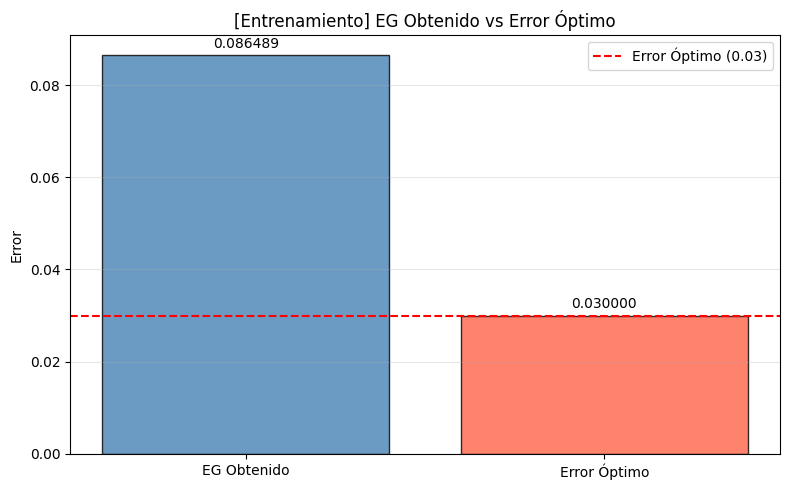

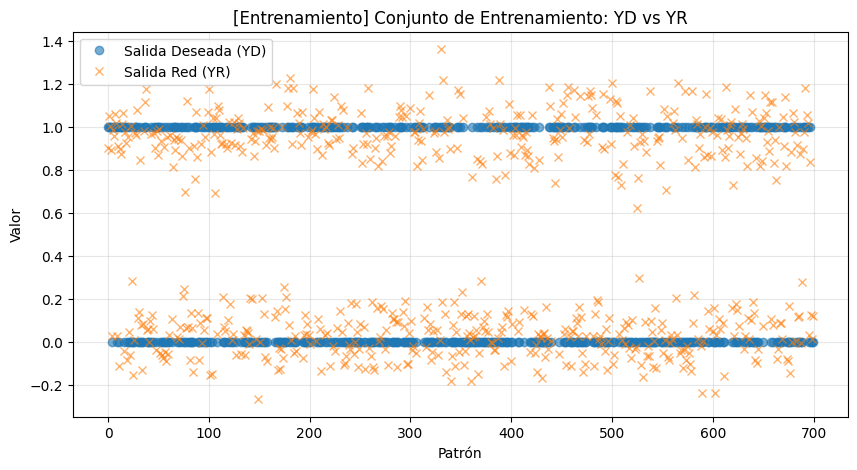

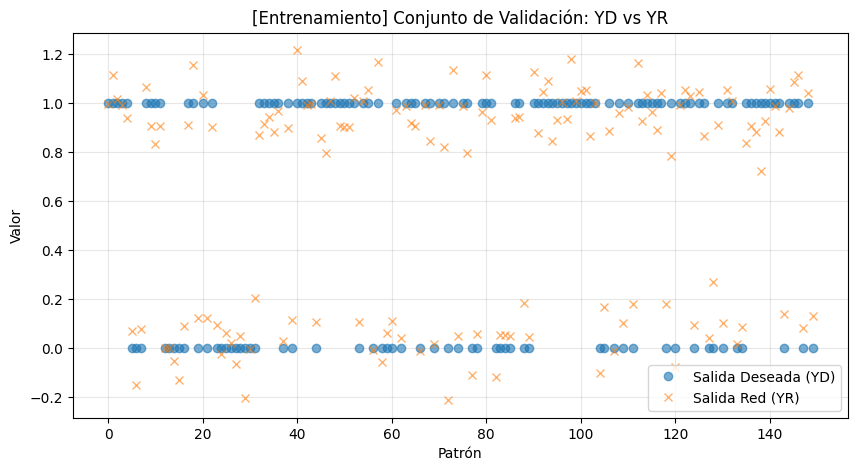

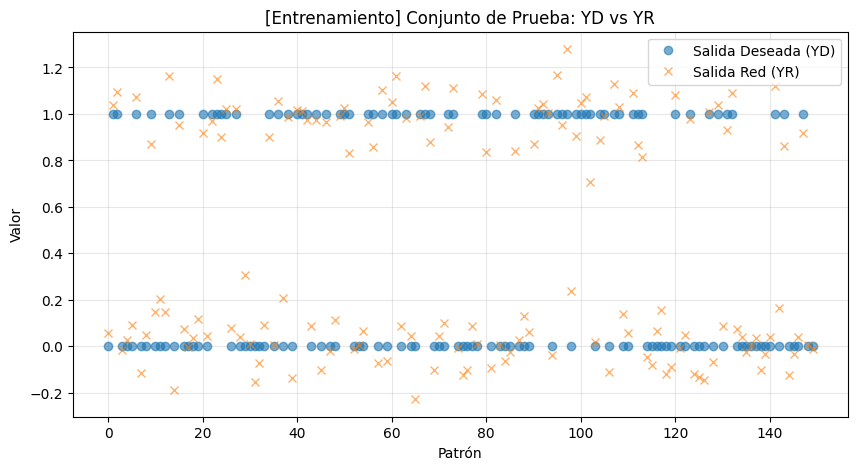

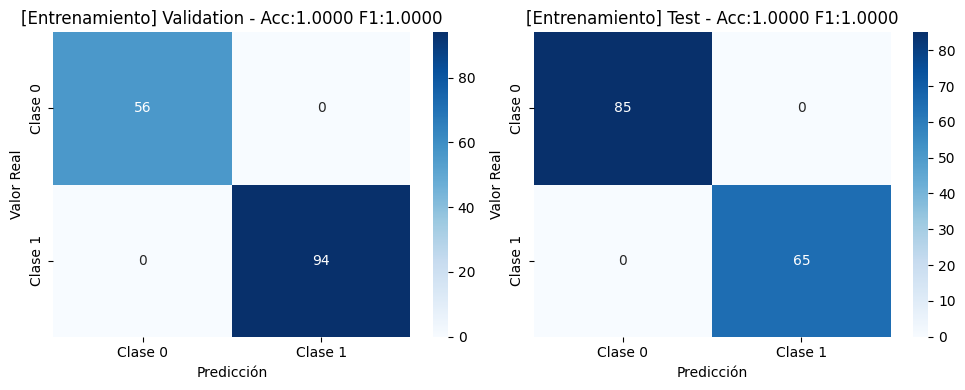

In [10]:
# Determinar número de clases desde los datos
n_clases = len(np.unique(YD))

graficar_todo(
    tag='Entrenamiento',
    YD_train=YD_train, YR_train=YR_train,
    YD_val=YD_val,     YR_val=YR_val,
    YD_test=YD_test,   YR_test=YR_test,
    mat_val=mat_val,   acc_val=acc_val,   f1_val=f1_val,
    mat_test=mat_test, acc_test=acc_test, f1_test=f1_test,
    EG_obtenido=EG_train, error_ref=error_optimo,
    n_clases=n_clases
)

## 10. Ajuste Manual de Parámetros (opcional)
Si quieres cambiar la configuración antes de reentrenar, modifica aquí y re-ejecuta desde la celda 6.

In [11]:
# Descomenta y modifica los valores que quieras ajustar:
# num_centros        = 30
# error_optimo       = 0.03
# max_iteraciones    = 15
# incremento_centros = 10

print("=== AJUSTE MANUAL ===")
print(f"  num_centros:        {num_centros}")
print(f"  error_optimo:       {error_optimo}")
print(f"  max_iteraciones:    {max_iteraciones}")
print(f"  incremento_centros: {incremento_centros}")

=== AJUSTE MANUAL ===
  num_centros:        4
  error_optimo:       0.03
  max_iteraciones:    15
  incremento_centros: 10


## 11. Reentrenamiento con Mejores Hiperparámetros
Ejecuta esta sección si el modelo no convergió o deseas mejorar el rendimiento.
Produce exactamente la misma información y gráficas que el entrenamiento original.

In [12]:
print("=" * 60)
print("REENTRENAMIENTO CON MEJORES HIPERPARÁMETROS")
print("=" * 60)

# ── Guardar métricas del entrenamiento anterior ──────────────
EG_anterior          = mejor_EG
MSE_anterior         = MSE_train
MSR_anterior         = MSR_train
centros_anteriores   = mejor_R.shape[0]
acc_val_anterior     = acc_val
prec_val_anterior    = prec_val
rec_val_anterior     = rec_val
spec_val_anterior    = spec_val
f1_val_anterior      = f1_val
acc_test_anterior    = acc_test
prec_test_anterior   = prec_test
rec_test_anterior    = rec_test
spec_test_anterior   = spec_test
f1_test_anterior     = f1_test

print(f"\nMétricas del entrenamiento ANTERIOR:")
print(f"  Centros: {centros_anteriores}  |  EG: {EG_anterior:.6f}  |  MSE: {MSE_anterior:.6f}  |  MSR: {MSR_anterior:.6f}")

# ── Configuración mejorada ────────────────────────────────────
num_centros_re  = num_centros * 2
error_optimo_re = error_optimo * 0.5

print(f"\nConfiguración MEJORADA:")
print(f"  Centros:      {centros_anteriores} → {num_centros_re} (x2)")
print(f"  Error Óptimo: {error_optimo} → {error_optimo_re} (x0.5 — más estricto)")

# ── Entrenamiento ─────────────────────────────────────────────
print(f"\n--- Iniciando reentrenamiento (una sola pasada) ---")
np.random.seed(100)
R_re = inicializar_centros(X_train, num_centros_re)
D_re = calcular_distancias(X_train, R_re)
A_re = calcular_matriz_interpolacion(D_re)
W_re = resolver_pesos(A_re, YD_train)

YR_train_re = simular_red(X_train, R_re, W_re)
EL_re, EG_re, MSE_re, MSR_re = calcular_errores(YD_train, YR_train_re)

converge_re = EG_re <= error_optimo_re

print(f"\nResultados del reentrenamiento (TRAIN):")
print(f"  Error General (EG): {EG_re:.6f}")
print(f"  Error Óptimo:       {error_optimo_re}")
print(f"  MSE:                {MSE_re:.6f}")
print(f"  MSR:                {MSR_re:.6f}")
print(f"\n{'✓ CONVERGIÓ' if converge_re else '✗ NO convergió'} con {num_centros_re} centros.")

# ── Evaluación en Val y Test ──────────────────────────────────
YR_val_re  = simular_red(X_val,  R_re, W_re)
EL_val_re,  EG_val_re,  MSE_val_re,  MSR_val_re  = calcular_errores(YD_val,  YR_val_re)

YR_test_re = simular_red(X_test, R_re, W_re)
EL_test_re, EG_test_re, MSE_test_re, MSR_test_re = calcular_errores(YD_test, YR_test_re)

print(f"\n  {'Conjunto':<18} {'EG':<12} {'MSE':<12} {'MSR':<12}")
print(f"  {'-'*54}")
print(f"  {'Train (70%)':<18} {EG_re:<12.6f}      {MSE_re:<12.6f}      {MSR_re:<12.6f}")
print(f"  {'Validation (15%)':<18} {EG_val_re:<12.6f}  {MSE_val_re:<12.6f}  {MSR_val_re:<12.6f}")
print(f"  {'Test (15%)':<18} {EG_test_re:<12.6f}  {MSE_test_re:<12.6f}  {MSR_test_re:<12.6f}")

# ── Matrices de confusión ─────────────────────────────────────
print(f"\n=== MATRICES DE CONFUSIÓN Y 5 MÉTRICAS — REENTRENAMIENTO ===")

mat_val_re,  acc_val_re,  prec_val_re,  rec_val_re,  spec_val_re,  f1_val_re  = calcular_matriz_confusion(YD_val,  YR_val_re)
mat_test_re, acc_test_re, prec_test_re, rec_test_re, spec_test_re, f1_test_re = calcular_matriz_confusion(YD_test, YR_test_re)

imprimir_metricas_conjunto("VALIDATION SET (Reentrenamiento)", len(X_val),
    acc_val_re,  prec_val_re,  rec_val_re,  spec_val_re,  f1_val_re,
    EG_val_re,  MSE_val_re,  MSR_val_re,  mat_val_re)

imprimir_metricas_conjunto("TEST SET (Reentrenamiento)", len(X_test),
    acc_test_re, prec_test_re, rec_test_re, spec_test_re, f1_test_re,
    EG_test_re, MSE_test_re, MSR_test_re, mat_test_re)

# ── Comparación con entrenamiento anterior ────────────────────
print(f"\n=== COMPARACIÓN: ENTRENAMIENTO vs REENTRENAMIENTO ===")
print(f"  {'Métrica':<20} {'Entrenamiento':<18} {'Reentrenamiento':<18} {'Mejora?'}")
print(f"  {'-'*70}")
rows = [
    ('Centros',      centros_anteriores,  num_centros_re,   num_centros_re > centros_anteriores),
    ('EG (train)',   EG_anterior,         EG_re,            EG_re         < EG_anterior),
    ('MSE (train)',  MSE_anterior,        MSE_re,           MSE_re        < MSE_anterior),
    ('MSR (train)',  MSR_anterior,        MSR_re,           MSR_re        > MSR_anterior),
    ('EG (val)',     EG_val,              EG_val_re,        EG_val_re     < EG_val),
    ('EG (test)',    EG_test,             EG_test_re,       EG_test_re    < EG_test),
    ('Acc (val)',    acc_val_anterior,    acc_val_re,       acc_val_re    >= acc_val_anterior),
    ('F1 (val)',     f1_val_anterior,     f1_val_re,        f1_val_re     >= f1_val_anterior),
    ('Acc (test)',   acc_test_anterior,   acc_test_re,      acc_test_re   >= acc_test_anterior),
    ('F1 (test)',    f1_test_anterior,    f1_test_re,       f1_test_re    >= f1_test_anterior),
]
for nombre, ant, nuevo, mejor in rows:
    if isinstance(ant, int):
        print(f"  {nombre:<20} {ant:<18} {nuevo:<18} {'✓' if mejor else '✗'}")
    else:
        print(f"  {nombre:<20} {ant:<18.6f} {nuevo:<18.6f} {'✓' if mejor else '✗'}")

REENTRENAMIENTO CON MEJORES HIPERPARÁMETROS

Métricas del entrenamiento ANTERIOR:
  Centros: 4  |  EG: 0.086489  |  MSE: 0.011595  |  MSR: 0.238240

Configuración MEJORADA:
  Centros:      4 → 8 (x2)
  Error Óptimo: 0.03 → 0.015 (x0.5 — más estricto)

--- Iniciando reentrenamiento (una sola pasada) ---

Resultados del reentrenamiento (TRAIN):
  Error General (EG): 0.071629
  Error Óptimo:       0.015
  MSE:                0.007937
  MSR:                0.241898

✗ NO convergió con 8 centros.

  Conjunto           EG           MSE          MSR         
  ------------------------------------------------------
  Train (70%)        0.071629          0.007937          0.241898    
  Validation (15%)   0.068632      0.007375      0.217959    
  Test (15%)         0.066158      0.006962      0.251312    

=== MATRICES DE CONFUSIÓN Y 5 MÉTRICAS — REENTRENAMIENTO ===

VALIDATION SET (Reentrenamiento) (150 patrones):
  Accuracy:    1.0000
  Precision:   1.0000
  Recall:      1.0000
  Specificity

### Gráficas del Reentrenamiento

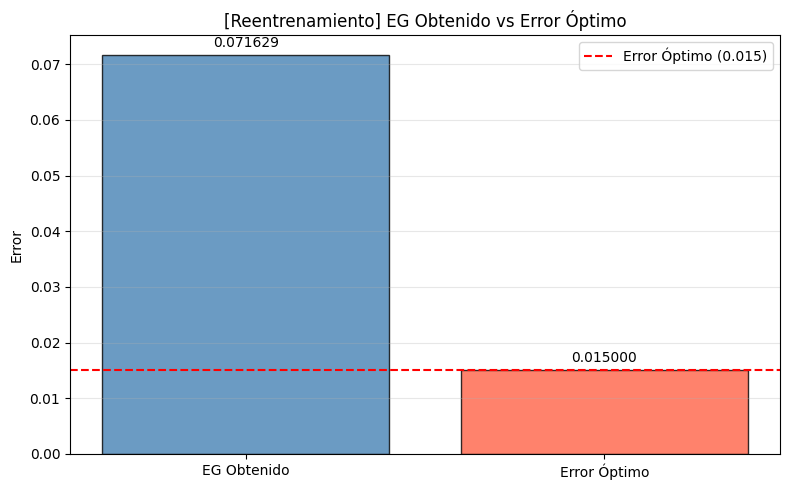

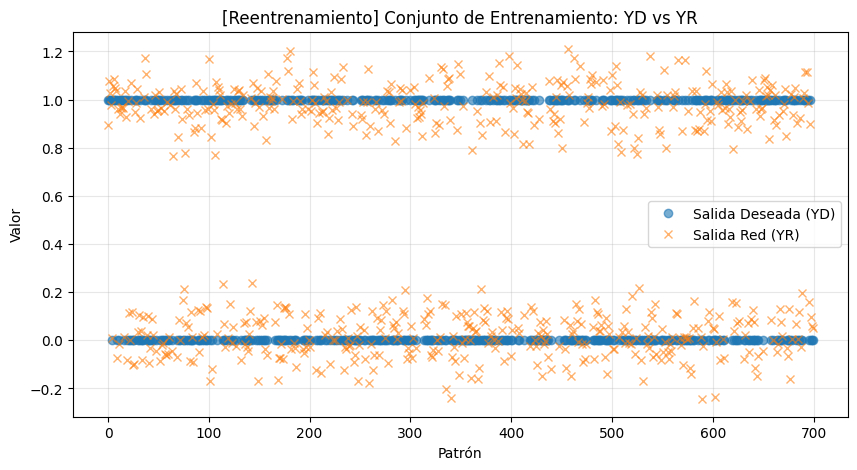

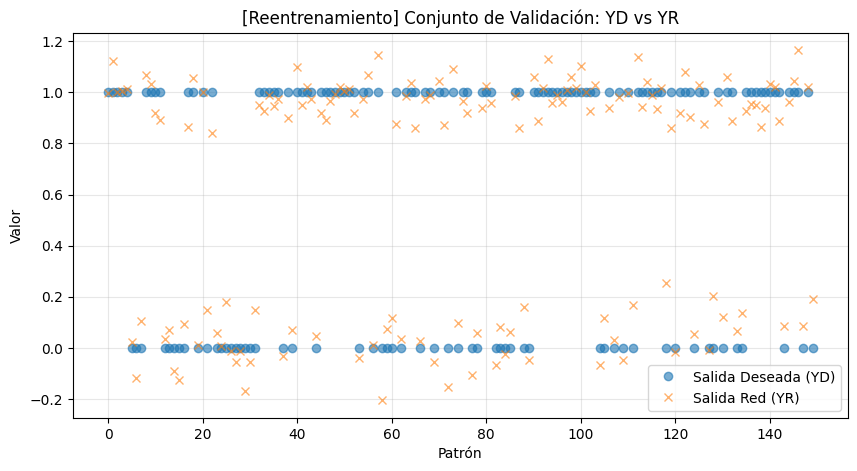

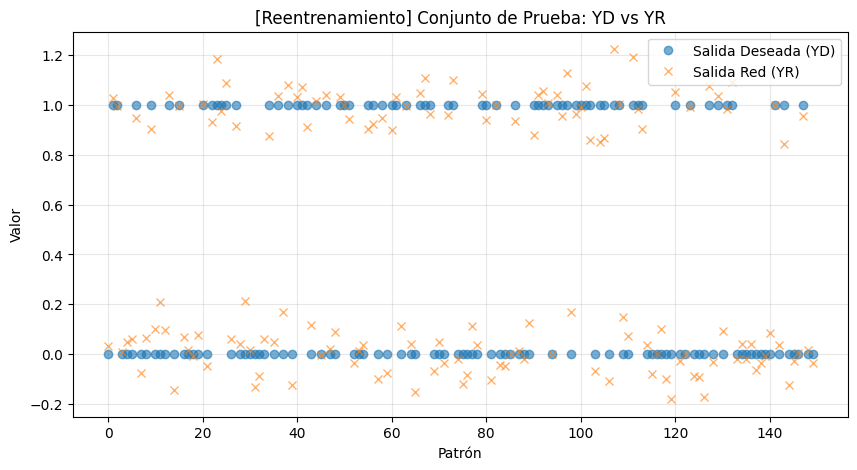

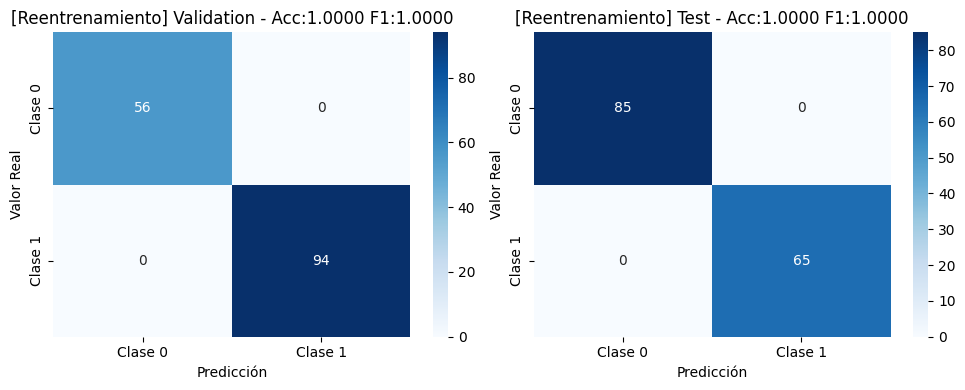

In [13]:
graficar_todo(
    tag='Reentrenamiento',
    YD_train=YD_train,   YR_train=YR_train_re,
    YD_val=YD_val,       YR_val=YR_val_re,
    YD_test=YD_test,     YR_test=YR_test_re,
    mat_val=mat_val_re,  acc_val=acc_val_re,  f1_val=f1_val_re,
    mat_test=mat_test_re,acc_test=acc_test_re,f1_test=f1_test_re,
    EG_obtenido=EG_re, error_ref=error_optimo_re,
    n_clases=n_clases
)

## 12. Resumen Final
Incluye resultados del entrenamiento **y** del reentrenamiento (si fue ejecutado).

In [14]:
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("RESUMEN FINAL DEL ENTRENAMIENTO")
print(SEP)

print(f"\nDataset: {dataset_name}")
print(f"Total de patrones: {len(X)}")
print(f"  - Entrenamiento (70%): {len(X_train)}")
print(f"  - Validación (15%):    {len(X_val)}")
print(f"  - Prueba (15%):        {len(X_test)}")

# ──────────────────────────────────────────────────────────────
print(f"\n{sep}")
print("PRIMER ENTRENAMIENTO")
print(sep)
print(f"  Centros:             {mejor_R.shape[0]}")
print(f"  Función activación:  Thin Plate Spline")
print(f"  Error objetivo:      {error_optimo}")
print(f"  Convergencia:        {'SÍ' if converge else 'NO'}")

print(f"\n  Errores:")
print(f"    {'Conjunto':<18} {'EG':<12} {'MSE':<12} {'MSR':<12}")
print(f"    {'-'*54}")
print(f"    {'Train (70%)':<18} {EG_train:<12.6f} {MSE_train:<12.6f} {MSR_train:<12.6f}")
print(f"    {'Validation (15%)':<18} {EG_val:<12.6f} {MSE_val:<12.6f} {MSR_val:<12.6f}")
print(f"    {'Test (15%)':<18} {EG_test:<12.6f} {MSE_test:<12.6f} {MSR_test:<12.6f}")

print(f"\n  Métricas de clasificación (Validation y Test):")
print(f"    {'Conjunto':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'Specificity':<13} {'F1-Score'}")
print(f"    {'-'*72}")
print(f"    {'Validation':<15} {acc_val:<12.4f} {prec_val:<12.4f} {rec_val:<12.4f} {spec_val:<13.4f} {f1_val:.4f}")
print(f"    {'Test':<15} {acc_test:<12.4f} {prec_test:<12.4f} {rec_test:<12.4f} {spec_test:<13.4f} {f1_test:.4f}")

# ──────────────────────────────────────────────────────────────
# Bloque de reentrenamiento: solo se imprime si fue ejecutado
try:
    _ = R_re  # comprueba si el reentrenamiento fue ejecutado
    print(f"\n{sep}")
    print("REENTRENAMIENTO")
    print(sep)
    print(f"  Centros:             {num_centros_re}")
    print(f"  Función activación:  Thin Plate Spline")
    print(f"  Error objetivo:      {error_optimo_re}")
    print(f"  Convergencia:        {'SÍ' if converge_re else 'NO'}")

    print(f"\n  Errores:")
    print(f"    {'Conjunto':<18} {'EG':<12} {'MSE':<12} {'MSR':<12}")
    print(f"    {'-'*54}")
    print(f"    {'Train (70%)':<18} {EG_re:<12.6f}     {MSE_re:<12.6f}     {MSR_re:<12.6f}")
    print(f"    {'Validation (15%)':<18} {EG_val_re:<12.6f} {MSE_val_re:<12.6f} {MSR_val_re:<12.6f}")
    print(f"    {'Test (15%)':<18} {EG_test_re:<12.6f} {MSE_test_re:<12.6f} {MSR_test_re:<12.6f}")

    print(f"\n  Métricas de clasificación (Validation y Test):")
    print(f"    {'Conjunto':<15} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'Specificity':<13} {'F1-Score'}")
    print(f"    {'-'*72}")
    print(f"    {'Validation':<15} {acc_val_re:<12.4f} {prec_val_re:<12.4f} {rec_val_re:<12.4f} {spec_val_re:<13.4f} {f1_val_re:.4f}")
    print(f"    {'Test':<15} {acc_test_re:<12.4f} {prec_test_re:<12.4f} {rec_test_re:<12.4f} {spec_test_re:<13.4f} {f1_test_re:.4f}")

    print(f"\n  Comparación (Entrenamiento → Reentrenamiento):")
    print(f"    {'Métrica':<20} {'Entren.':<14} {'Reentr.':<14} {'Mejora?'}")
    print(f"    {'-'*55}")
    resumen_rows = [
        ('EG train',   EG_anterior,       EG_re,       EG_re       < EG_anterior),
        ('MSE train',  MSE_anterior,      MSE_re,      MSE_re      < MSE_anterior),
        ('EG val',     EG_val,            EG_val_re,   EG_val_re   < EG_val),
        ('EG test',    EG_test,           EG_test_re,  EG_test_re  < EG_test),
        ('Acc val',    acc_val_anterior,  acc_val_re,  acc_val_re  >= acc_val_anterior),
        ('F1 val',     f1_val_anterior,   f1_val_re,   f1_val_re   >= f1_val_anterior),
        ('Acc test',   acc_test_anterior, acc_test_re, acc_test_re >= acc_test_anterior),
        ('F1 test',    f1_test_anterior,  f1_test_re,  f1_test_re  >= f1_test_anterior),
    ]
    for nombre, ant, nuevo, mejor in resumen_rows:
        print(f"    {nombre:<20} {ant:<14.6f} {nuevo:<14.6f} {'✓' if mejor else '✗'}")
except NameError:
    print(f"\n[Reentrenamiento no ejecutado — sección 11 no corrida]")

print(f"\n{SEP}")

RESUMEN FINAL DEL ENTRENAMIENTO

Dataset: clasificacion_2_clases_grande
Total de patrones: 1000
  - Entrenamiento (70%): 700
  - Validación (15%):    150
  - Prueba (15%):        150

-----------------------------------------------------------------
PRIMER ENTRENAMIENTO
-----------------------------------------------------------------
  Centros:             4
  Función activación:  Thin Plate Spline
  Error objetivo:      0.03
  Convergencia:        NO

  Errores:
    Conjunto           EG           MSE          MSR         
    ------------------------------------------------------
    Train (70%)        0.086489     0.011595     0.238240    
    Validation (15%)   0.083720     0.010628     0.214111    
    Test (15%)         0.081196     0.010362     0.249981    

  Métricas de clasificación (Validation y Test):
    Conjunto        Accuracy     Precision    Recall       Specificity   F1-Score
    ------------------------------------------------------------------------
    Validation 